## **Exercise 01 : Line chart with styles**

In [1]:
import pandas as pd
import sqlite3

# analyze only the users and not the admins
# analyze only the dates when there were both views and checker commits
# use size of the font should be 8
# the size of the figure is (15,8)

pd.set_option('display.max_rows', 10)
connection = sqlite3.connect('../data/checking-logs.sqlite')
pageviews_visits = pd.read_sql('select datetime as views from pageviews where uid like "%user_%"', connection)
pageviews_visits['views'] = pd.to_datetime(pageviews_visits['views']).dt.strftime('%Y-%m-%d')
pageviews_visits = pageviews_visits.groupby('views')['views'].count()
pageviews_visits

views
2020-04-17     1
2020-04-18    23
2020-04-19    15
2020-04-21     3
2020-04-22     1
              ..
2020-05-18    51
2020-05-19    11
2020-05-20    12
2020-05-21    11
2020-05-22     2
Name: views, Length: 33, dtype: int64

In [2]:
commits = pd.read_sql('select timestamp as commits from checker where uid like "%user_%"', connection)
commits['commits'] = pd.to_datetime(commits['commits']).dt.strftime('%Y-%m-%d')
commits = commits.groupby('commits')['commits'].count()
commits

commits
2020-04-17    23
2020-04-18    69
2020-04-19    33
2020-04-20    25
2020-04-21    25
              ..
2020-05-17    48
2020-05-18     3
2020-05-19    34
2020-05-20    28
2020-05-21    49
Name: commits, Length: 35, dtype: int64

In [3]:
to_plot = pd.concat([pageviews_visits, commits], axis=1)
to_plot.dropna(inplace=True)
to_plot

,views,commits
2020-04-17,1.0,23.0
2020-04-18,23.0,69.0
2020-04-19,15.0,33.0
2020-04-21,3.0,25.0
2020-04-22,1.0,28.0
...,...,...
2020-05-17,9.0,48.0
2020-05-18,51.0,3.0
2020-05-19,11.0,34.0
2020-05-20,12.0,28.0


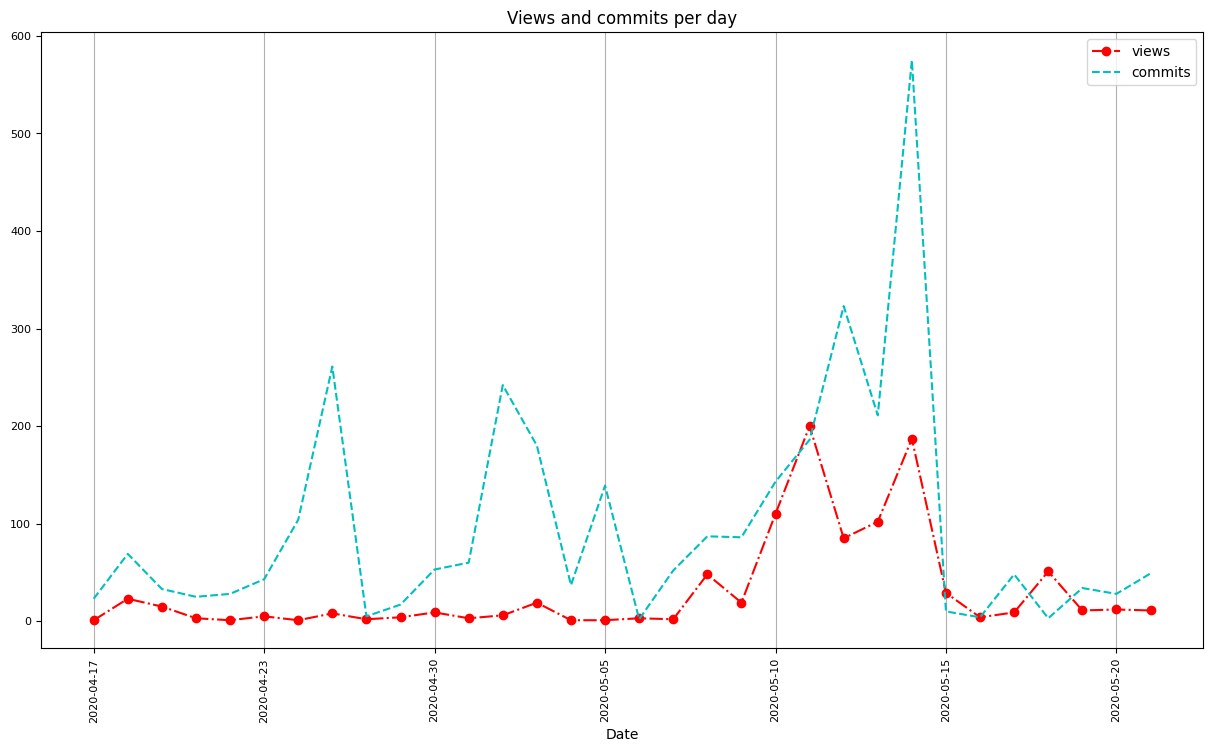

In [4]:
# the size of the font should be 8
# the size of the figure is (15,8)
# the graph must have the title Views per day
# notice the rotation of xticks on the graph below
to_plot.index.name='Date'
to_plot['views'].plot(fontsize=8, figsize = (15,8), title='Views and commits per day', rot=90, linestyle='-.', c = "r", marker="o", label='views', legend='upper right')
ax = to_plot['commits'].plot(linestyle='--', c = "c", rot=90, label='commits', legend='upper right')
ax.grid('on', which='major', axis='x')

In [5]:
# close the connection to the database
connection.close()

In [6]:
int(pageviews_visits.loc[pageviews_visits >150].count())

2

“How many times was the number of views larger than 150?”
The answer is 2